In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('AirPassNew.csv')

In [3]:
# Количество строк и столбцов
df.shape

(10366, 25)

In [4]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [5]:
# Пропуски по столбцам
print(df.isnull().sum())
print(df.isnull().sum() / len(df) * 100)

Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             26
satisfaction                          0


**Вывод по пропускам:**  
Пропуски есть только в столбце Arrival Delay in Minutes (26 пропусков).

In [6]:
# Удаляем строки с пропусками
df = df.dropna()

Пропуски составили менее 0,3% данных, поэтому строки были удалены.

In [7]:
# Проверим, что пропусков нет
print('Количество пропусков:', df.isnull().sum().sum())
print('Количество строк после удаления пропусков', df.shape[0])

Количество пропусков: 0
Количество строк после удаления пропусков 10340


In [8]:
# Проверим, есть ли дубли
duplicates_count = df.duplicated().sum()
print('Найдено дублей:', duplicates_count)

Найдено дублей: 0


In [9]:
# Проверим распределение удовлетворенных и неудовлетворенных пассажиров
pd.concat([df['satisfaction'].value_counts(), df['satisfaction'].value_counts(normalize = True).round(2).mul(100)], axis = 1, keys = ['количество','процент'])

,количество,процент
neutral or dissatisfied,5871,57.0
satisfied,4469,43.0


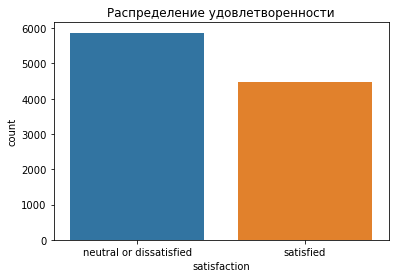

In [10]:
# Построим график распределения удовлетворенности
sns.countplot(x = 'satisfaction', data = df)
plt.title('Распределение удовлетворенности');

In [11]:
# Создадим столбец, в котором значению neutral or dissatisfied будет соответствовать 0, а значению satisfied 1
df['satisfaction_0_1'] = df['satisfaction'].apply(lambda x: 1 if x == 'satisfied' else 0)

In [12]:
# Создадим столбец с категориями задержки
def delay_category(minutes):
    if minutes <= 0:
        return '1. Без задержки'
    elif minutes <= 15:
        return '2. До 15 мин'
    elif minutes <= 30:
        return '3. 15-30 мин'
    elif minutes <= 60:
        return '4. 30-60 мин'
    elif minutes <= 120:
        return '5. 1-2 часа'
    else:
        return '6. Более 2 часов'

df['Departure delay category'] = df['Departure Delay in Minutes'].apply(delay_category)

In [13]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,satisfaction_0_1,Departure delay category
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,3,4,4,5,5,25,18.0,neutral or dissatisfied,0,3. 15-30 мин
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,5,3,1,4,1,1,6.0,neutral or dissatisfied,0,2. До 15 мин
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,3,4,4,4,5,0,0.0,satisfied,1,1. Без задержки
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,5,3,1,4,2,11,9.0,neutral or dissatisfied,0,2. До 15 мин
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,4,4,3,3,3,0,0.0,satisfied,1,1. Без задержки


In [14]:
# Посмотрим, сколько пассажиров в каждой группе задержки
df['Departure delay category'].value_counts()

1. Без задержки     5808
2. До 15 мин        2213
3. 15-30 мин         897
4. 30-60 мин         721
5. 1-2 часа          443
6. Более 2 часов     258
Name: Departure delay category, dtype: int64

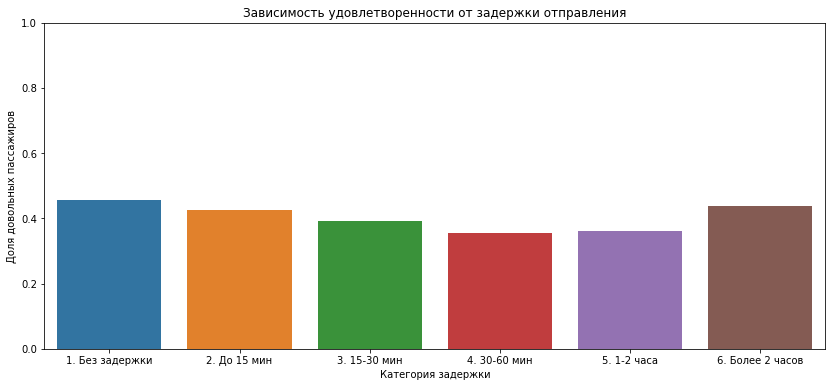

In [15]:
# Посчитаем среднюю удовлетворенность по категориям задержки и построим график
departure_delay_satisfaction = df.groupby('Departure delay category')['satisfaction_0_1'].mean().reset_index()

plt.figure(figsize=(14,6))
sns.barplot(data = departure_delay_satisfaction, x = 'Departure delay category', y = 'satisfaction_0_1')
plt.title('Зависимость удовлетворенности от задержки отправления')
plt.xlabel('Категория задержки')
plt.ylabel('Доля довольных пассажиров')
plt.ylim(0, 1)
plt.show()

In [16]:
print(departure_delay_satisfaction)

  Departure delay category  satisfaction_0_1
0          1. Без задержки          0.455923
1             2. До 15 мин          0.425215
2             3. 15-30 мин          0.391304
3             4. 30-60 мин          0.355062
4              5. 1-2 часа          0.361174
5         6. Более 2 часов          0.437984


**Вывод по влиянию задержек:**  
С ростом задержки удовлетворенность постепенно снижается:
- Без задержки - 44,9% довольных
- Задержка до 15 минут - 41,9%
- Задержка 15-30 минут - 38,4%
- Задержка 30-60 минут - 34,9%

**Замечание:**  
При задержках 1-2 часа удовлетворенность практически не отличается от группы 30-60 минут, а при задержке более 2 часов неожиданно повышается до 43,8% - почти до уровня "без задержки".

Это требует дополнительного анализа.

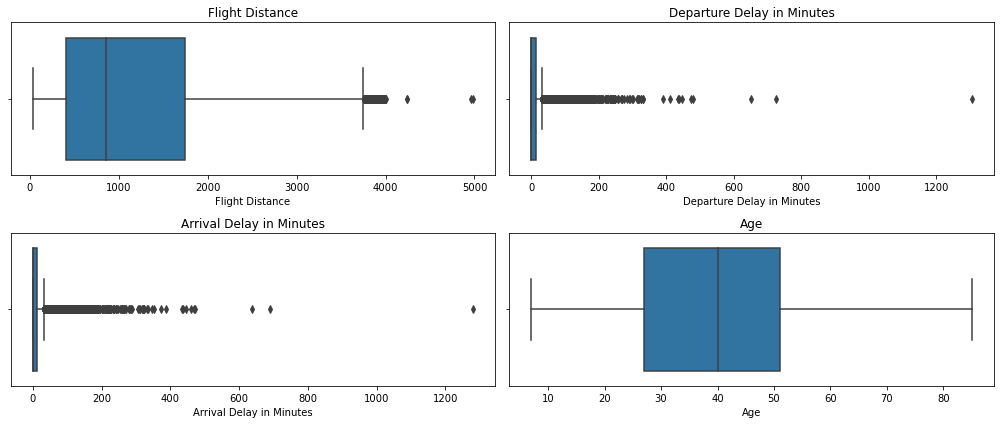

In [17]:
# Проверим выбросы для столбцов с числовыми данными
fig, ax = plt.subplots(2, 2, figsize=(14, 6))
cols = ['Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Age']
axes_flat = ax.flatten()

for i in range(4):
    sns.boxplot(data=df, x=cols[i], ax=axes_flat[i])
    axes_flat[i].set_title(cols[i])

plt.tight_layout()
plt.show()

**Анализ выбросов:**   
Анализ проведен для числовых признаков: Flight Distance, Departure Delay, Arrival Delay, Age. Оценки сервиса (1–5) не имеют выбросов. Много выбросов в столбцах: Flight Distance, Departure Delay in Minutes и Arrival Delay in Minutes.

In [18]:
# Функция для удаления выбросов по IQR
def outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [19]:
# Посчитаем количество выбросов по IQR в столбцах
print('Количество выбросов по IQR в столбце: ')
for col in cols[:-1]:
    print(f'{col}: {len(df) - len(outliers_iqr(df, col))}')

Количество выбросов по IQR в столбце: 
Flight Distance: 208
Departure Delay in Minutes: 1349
Arrival Delay in Minutes: 1398


In [20]:
# Удалим выбросы в столбце Flight Distance
df_clean = outliers_iqr(df, 'Flight Distance')

In [21]:
print(f'В столбце Flight Distance было удалено {len(df) - len(df_clean)} выбросов')
print('Количество строк после удаления выбросов в столбце Flight Distance', len(df_clean))

В столбце Flight Distance было удалено 208 выбросов
Количество строк после удаления выбросов в столбце Flight Distance 10132


**Вывод по очистке:**  
Для столбца Flight Distance удалены выбросы по IQR (208 строк). Выбросы в задержках не удалялись, так как это редкие, но реальные события, важные для анализа удовлетворенности при сбоях.

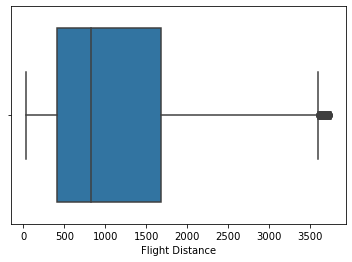

In [22]:
# Проверим, что выбросы удалены
sns.boxplot(data = df_clean, x = 'Flight Distance');

**Вывод по очистке от выбросов:**  
Были удалены экстремальные значения.

**Гипотеза 1:**  
Длинные перелеты снижают удовлетворенность.

In [23]:
# Сгруппируем по классу и посчитаем корреляцию 
df_clean.groupby('Class')[['Flight Distance', 'satisfaction_0_1']].corr()

Flight Distance  satisfaction_0_1
Class                                                       
Business Flight Distance          1.000000          0.145741
         satisfaction_0_1         0.145741          1.000000
Eco      Flight Distance          1.000000         -0.029401
         satisfaction_0_1        -0.029401          1.000000
Eco Plus Flight Distance          1.000000         -0.068377
         satisfaction_0_1        -0.068377          1.000000

In [24]:
# Сгруппируем по лояльности и посчитаем корреляцию
df_clean.groupby('Customer Type')[['Flight Distance', 'satisfaction_0_1']].corr()

Flight Distance  satisfaction_0_1
Customer Type                                                        
Loyal Customer    Flight Distance          1.000000          0.286537
                  satisfaction_0_1         0.286537          1.000000
disloyal Customer Flight Distance          1.000000          0.006614
                  satisfaction_0_1         0.006614          1.000000

In [25]:
# Сгруппируем по типу поездки и посчитаем корреляцию
df_clean.groupby('Type of Travel')[['Flight Distance', 'satisfaction_0_1']].corr()

Flight Distance  satisfaction_0_1
Type of Travel                                                     
Business travel Flight Distance          1.000000          0.227371
                satisfaction_0_1         0.227371          1.000000
Personal Travel Flight Distance          1.000000          0.037093
                satisfaction_0_1         0.037093          1.000000

**Вывод по гипотезе 1 (не подтвердилась):**  
Корреляция близка к нулю во всех классах (бизнес, эконом плюс, эконом), для личных поездок и для нелояльных пассажиров. Слабая корреляция наблюдается у лояльных пассажиров и для деловых поездок.  
**Итог:**  
Длина перелета не является значимым фактором.

**Гипотеза 2:**  
Лояльность влияет на удовлетворенность.

In [26]:
# Посчитаем среднюю удовлетворенность по лояльности пассажира
print(df_clean.groupby('Customer Type')['satisfaction_0_1'].mean())

Customer Type
Loyal Customer       0.469528
disloyal Customer    0.232009
Name: satisfaction_0_1, dtype: float64


**Вывод по гипотезе 2 (подтвердилась):**  
В среднем лояльные пассажиры более удовлетворены (на 24%).

**Гипотеза 3:**  
Класс обслуживания влияет на удовлетворенность.

In [27]:
# Посчитаем среднюю удовлетворенность по классу обслуживания
print(df_clean.groupby('Class')['satisfaction_0_1'].mean())

Class
Business    0.682360
Eco         0.190093
Eco Plus    0.238667
Name: satisfaction_0_1, dtype: float64


**Вывод по гипотезе 3 (подтвердилась):**  
Пассажиры бизнес-класса значительно чаще удовлетворены сервисом (68%), чем пассажиры эконома (19%) и эконом-плюс (24%).

In [28]:
# Рассмотрим подробнее группу с самой долгой задержкой (более 2 часов)
long_delay = df_clean[df_clean['Departure delay category'] == '6. Более 2 часов']
print('Количество пассажиров в группе с задержкой более 2 часов:', len(long_delay))

Количество пассажиров в группе с задержкой более 2 часов: 256


In [29]:
# Посмотрим распределение по разным признакам
print("Распределение по классам:")
print(long_delay['Class'].value_counts(normalize=True).round(2))

print("Распределение по лояльности пассажира:")
print(long_delay['Customer Type'].value_counts(normalize=True).round(2))

print("Распределение по цели поездки:")
print(long_delay['Type of Travel'].value_counts(normalize=True).round(2))

Распределение по классам:
Business    0.51
Eco         0.44
Eco Plus    0.05
Name: Class, dtype: float64
Распределение по лояльности пассажира:
Loyal Customer       0.81
disloyal Customer    0.19
Name: Customer Type, dtype: float64
Распределение по цели поездки:
Business travel    0.75
Personal Travel    0.25
Name: Type of Travel, dtype: float64


**Вывод:**  
В этой группе 256 человек. Из них:
- 51% - бизнес-класс
- 81% - лояльные пассажиры
- 75% - деловые поездки

In [30]:
# Удовлетворенность по классу, лояльности пассажира и цели поездки
print("Удовлетворенность в группе с задержкой более 2 часов")
print("Общая удовлетворенность в группе:", round(long_delay['satisfaction_0_1'].mean(),2))

print("По классу:")
print(long_delay.groupby('Class')['satisfaction_0_1'].mean().round(2))

print("По лояльности пассажира:")
print(long_delay.groupby('Customer Type')['satisfaction_0_1'].mean().round(2))

print("По цели поездки:")
print(long_delay.groupby('Type of Travel')['satisfaction_0_1'].mean().round(2))

Удовлетворенность в группе с задержкой более 2 часов
Общая удовлетворенность в группе: 0.44
По классу:
Class
Business    0.68
Eco         0.16
Eco Plus    0.38
Name: satisfaction_0_1, dtype: float64
По лояльности пассажира:
Customer Type
Loyal Customer       0.48
disloyal Customer    0.27
Name: satisfaction_0_1, dtype: float64
По цели поездки:
Type of Travel
Business travel    0.55
Personal Travel    0.10
Name: satisfaction_0_1, dtype: float64


**Вывод:**  
Общая удовлетворенность в группе с задержкой более 2 часов - 44%. При этом удовлетворенность:
- в бизнес-классе 68%
- у лояльных пассажиров 48%
- во время деловых поездок 55%

In [31]:
# Построим сводную таблицу для оценки средней удовлетворенности по классу и лояльности в группе с сильной задержкой
pd.pivot_table(long_delay, 
               values='satisfaction_0_1', 
               index='Class', 
               columns='Customer Type', 
               aggfunc='mean').round(2)

Customer Type,Loyal Customer,disloyal Customer
Class,,
Business,0.72,0.38
Eco,0.15,0.20
Eco Plus,0.36,0.50


In [32]:
# Построим сводную таблицу для подсчета количества пассажиров по классу и лояльности в группе с сильной задержкой
pd.pivot_table(long_delay, 
               values='satisfaction_0_1', 
               index='Class', 
               columns='Customer Type', 
               aggfunc='count', 
                margins=True)

Customer Type,Loyal Customer,disloyal Customer,All
Class,,,
Business,115,16,131
Eco,82,30,112
Eco Plus,11,2,13
All,208,48,256


**Вывод:**  
При задержке более 2 часов программа лояльности повышает удовлетворенность только в бизнес-классе (+34%).
В экономе и эконом-плюс нелояльные пассажиры удовлетворены несколько больше, чем лояльные (разница -5% и -14% соответственно). Однако эти различия могут быть обусловлены малым количеством данных в некоторых подгруппах.

In [33]:
service = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 
           'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 
           'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

correlations = df[service + ['satisfaction_0_1']].corr()['satisfaction_0_1'].drop('satisfaction_0_1').sort_values(ascending=False)
print(correlations)

Online boarding                      0.496321
Inflight entertainment               0.411332
Seat comfort                         0.350960
On-board service                     0.323498
Leg room service                     0.323231
Cleanliness                          0.312630
Inflight wifi service                0.279801
Baggage handling                     0.258576
Inflight service                     0.250968
Food and drink                       0.229681
Checkin service                      0.218266
Ease of Online booking               0.160867
Gate location                       -0.003709
Departure/Arrival time convenient   -0.060883
Name: satisfaction_0_1, dtype: float64


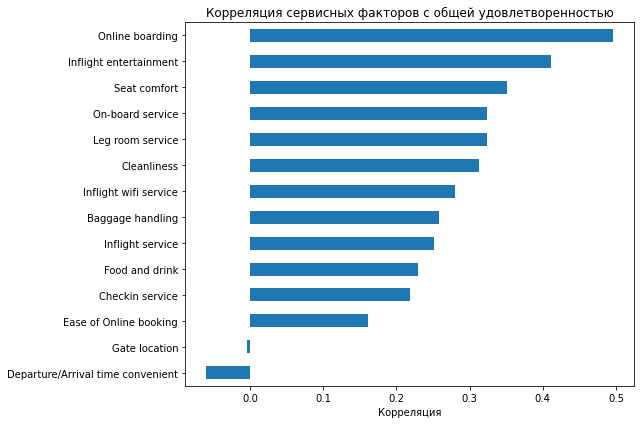

In [34]:
plt.figure(figsize=(9,6))
correlations.sort_values().plot(kind='barh')
plt.title('Корреляция сервисных факторов с общей удовлетворенностью')
plt.xlabel('Корреляция')
plt.tight_layout()
plt.show()

**Вывод по сервисным факторам:**  
Наибольшее влияние на общую удовлетворенность оказывают онлайн-регистрация, развлечения на борту и комфорт сидений. Расположение выхода и время вылета/прилета практически не влияют на удовлетворенность.

## Итоги анализа

1. **Задержки** снижают удовлетворенность. Исключение - группа с задержкой более 2 часов (удовлетворенность 44%), что объясняется высокой долей бизнес-класса (51%) и лояльных клиентов (81%).

2. **Класс обслуживания** сильно связан с удовлетворенностью: бизнес-класс - 68%, эконом - 19%.

3. **Лояльные клиенты** удовлетворены чаще (47% против 23% у нелояльных). Однако при задержке более 2 часов лояльность дает прирост только в бизнес-классе (+34%).

4. **Сервисные факторы** с наибольшей корреляцией: онлайн-регистрация (0,5), развлечения (0,41), комфорт сидений (0,35).

5. **Длина перелета** и **тип поездки** значимого влияния не показали.